# 03 - Ventanas, zero padding y potencia por bandas

Primero uso una señal conocida para ver la fuga espectral. Después repito la comparación sobre
dos muestras reales de DroneRF y agrego zero padding para separar lo que cambia en la
gráfica de lo que cambia en la resolución física.


In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

RAIZ = Path.cwd()
if RAIZ.name == "notebooks":
    RAIZ = RAIZ.parent

SRC = RAIZ / "src"
if str(SRC) not in sys.path:
    sys.path.insert(0, str(SRC))

from aps_drone_rf.config import FIGURES_DIR, TABLES_DIR
from aps_drone_rf.demo import load_signal_input
from aps_drone_rf.estilo import COLOR_SERIE, COLORES, aplicar_estilo_matplotlib
from aps_drone_rf.plots import save_figure
from aps_drone_rf.spectral import (
    band_power,
    fft_magnitude,
    integrate_psd_power,
    welch_psd,
    window_metrics,
)

aplicar_estilo_matplotlib()


## Fuga espectral con una senoidal conocida

La frecuencia no coincide exactamente con un bin. Comparo rectangular, Hann, Hamming y
Blackman corrigiendo la ganancia coherente de cada ventana.


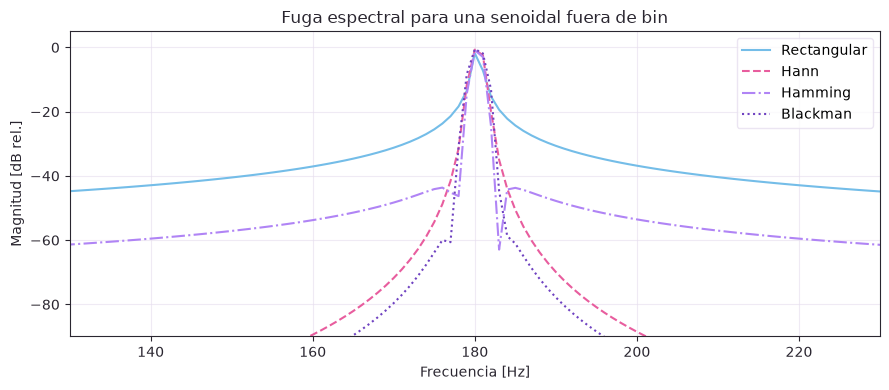

,ventana,ganancia_coherente,enbw_bins,enbw_hz
0,rectangular,1.00,1.0000,1.0000
1,hann,0.50,1.5000,1.5000
2,hamming,0.54,1.3628,1.3628
3,blackman,0.42,1.7268,1.7268


In [2]:
fs_sint = 2_000.0
N_sint = 2_000
f0 = 180.35
tt_sint = np.arange(N_sint) / fs_sint
xx_sint = np.sin(2 * np.pi * f0 * tt_sint)

nombres_ventana = ["rectangular", "hann", "hamming", "blackman"]
estilos = {"rectangular": "-", "hann": "--", "hamming": "-.", "blackman": ":"}
filas = []

fig, eje = plt.subplots(figsize=(9, 4))
for nombre in nombres_ventana:
    ff, magnitud, _ = fft_magnitude(xx_sint, fs_sint, window=nombre)
    datos = window_metrics(nombre, N_sint, fs_sint)
    eje.plot(
        ff,
        20 * np.log10(np.maximum(magnitud, 1e-15)),
        color=COLOR_SERIE[nombre],
        ls=estilos[nombre],
        label=nombre.title(),
    )
    filas.append({"ventana": nombre, **datos})

eje.set_xlim(130, 230)
eje.set_ylim(-90, 5)
eje.set_title("Fuga espectral para una senoidal fuera de bin")
eje.set_xlabel("Frecuencia [Hz]")
eje.set_ylabel("Magnitud [dB rel.]")
eje.legend()
save_figure(fig, FIGURES_DIR / "nb03_ventanas_fuga_espectral.png")
plt.show()

tabla_ventanas = pd.DataFrame(filas)
tabla_ventanas.to_csv(TABLES_DIR / "nb03_tabla_ventanas.csv", index=False)
display(tabla_ventanas.round(4))


 la rectangular deja un lóbulo principal angosto pero más energía
repartida en lóbulos laterales; Hann, Hamming y Blackman reducen esa fuga espectral con distinto
ensanchamiento.  no existe una ventana mejor para todo.  la
senoidal controlada ayuda a entender el método, pero no reemplaza el análisis de DroneRF.


## El mismo efecto sobre muestras reales de DroneRF

Uso la ventana L con índice 50 de una muestra excluida sin dron y de otra de Phantom
conectado. Las cuatro curvas parten exactamente de las mismas 1024 muestras.


C:\Users\msere\Repositorios\APS\src\aps_drone_rf\plots.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


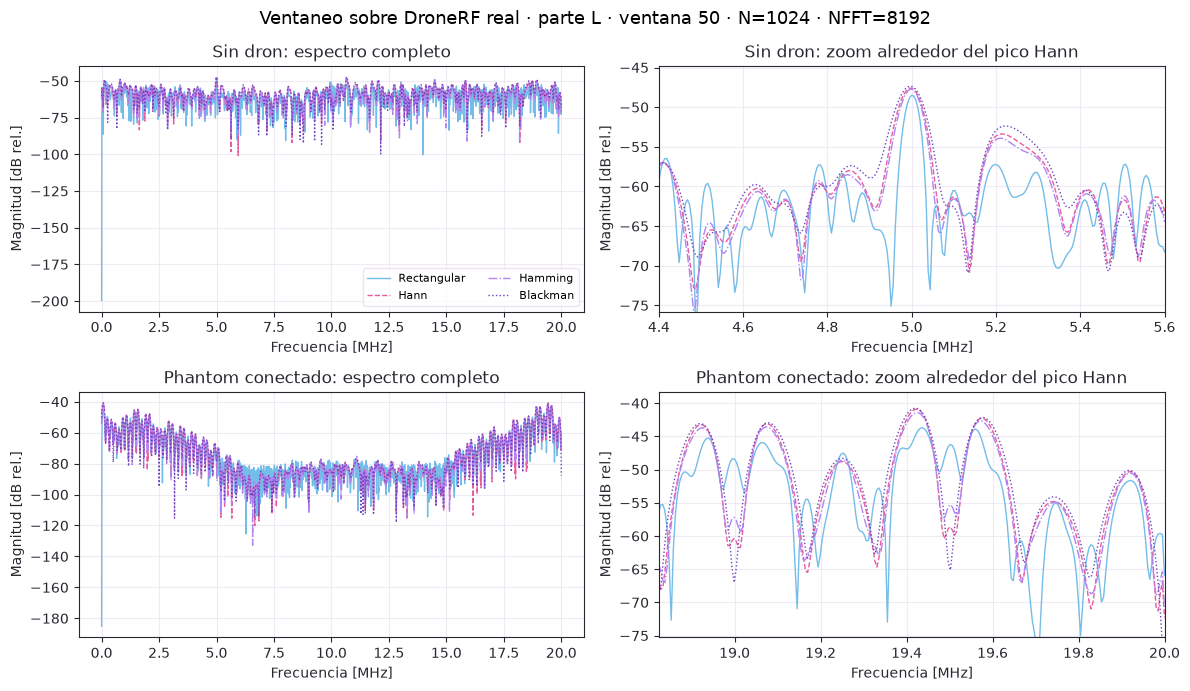

,muestra,ventana,ganancia_coherente,ENBW_bins,ENBW_kHz,pico_MHz
0,Sin dron,rectangular,1.00,1.0000,39.0625,5.0000
1,Sin dron,hann,0.50,1.5000,58.5938,5.0000
2,Sin dron,hamming,0.54,1.3628,53.2354,5.0000
3,Sin dron,blackman,0.42,1.7268,67.4515,10.6641
4,Phantom conectado,rectangular,1.00,1.0000,39.0625,19.4336
5,Phantom conectado,hann,0.50,1.5000,58.5938,19.4238
6,Phantom conectado,hamming,0.54,1.3628,53.2354,19.4238
7,Phantom conectado,blackman,0.42,1.7268,67.4515,0.0684


In [3]:
ruta_fondo = RAIZ / "muestras_demo" / "sin_dron" / "muestra_01.npz"
ruta_phantom = RAIZ / "muestras_demo" / "phantom" / "conectado" / "muestra_01.npz"
entrada_fondo = load_signal_input(ruta_fondo)
entrada_phantom = load_signal_input(ruta_phantom)

indice_ventana = 50
fs = entrada_phantom.fs_hz
N = entrada_phantom.window_sets["L"].shape[1]
NFFT = 8192
ventana_fondo = entrada_fondo.window_sets["L"][indice_ventana]
ventana_phantom = entrada_phantom.window_sets["L"][indice_ventana]

fig, ejes = plt.subplots(2, 2, figsize=(12, 7), constrained_layout=True)
filas_reales = []

for fila, (clase, xx) in enumerate(
    [("Sin dron", ventana_fondo), ("Phantom conectado", ventana_phantom)]
):
    resultados = {}
    for nombre in nombres_ventana:
        ff, magnitud, _ = fft_magnitude(
            xx, fs, n_fft=NFFT, window=nombre, detrend=True
        )
        resultados[nombre] = (ff, magnitud)
        datos = window_metrics(nombre, N, fs)
        filas_reales.append(
            {
                "muestra": clase,
                "ventana": nombre,
                "ganancia_coherente": datos["ganancia_coherente"],
                "ENBW_bins": datos["enbw_bins"],
                "ENBW_kHz": datos["enbw_hz"] / 1e3,
                "pico_MHz": ff[np.argmax(magnitud)] / 1e6,
            }
        )
        ejes[fila, 0].plot(
            ff / 1e6,
            20 * np.log10(np.maximum(magnitud, 1e-15)),
            color=COLOR_SERIE[nombre],
            ls=estilos[nombre],
            label=nombre.title(),
            lw=1.0,
        )

    f_hann, mag_hann = resultados["hann"]
    pico_hann = f_hann[np.argmax(mag_hann)]
    for nombre, (ff, magnitud) in resultados.items():
        ejes[fila, 1].plot(
            ff / 1e6,
            20 * np.log10(np.maximum(magnitud, 1e-15)),
            color=COLOR_SERIE[nombre],
            ls=estilos[nombre],
            label=nombre.title(),
            lw=1.0,
        )
    ejes[fila, 0].set_title(f"{clase}: espectro completo")
    ejes[fila, 1].set_title(f"{clase}: zoom alrededor del pico Hann")
    limite_zoom_bajo = max(0.0, pico_hann / 1e6 - 0.6)
    limite_zoom_alto = min(fs / 2e6, pico_hann / 1e6 + 0.6)
    ejes[fila, 1].set_xlim(limite_zoom_bajo, limite_zoom_alto)
    valores_zoom = []
    for ff, magnitud in resultados.values():
        mascara_zoom = (ff / 1e6 >= limite_zoom_bajo) & (ff / 1e6 <= limite_zoom_alto)
        valores_zoom.extend(20 * np.log10(np.maximum(magnitud[mascara_zoom], 1e-15)))
    valores_zoom = np.asarray(valores_zoom)
    ejes[fila, 1].set_ylim(
        np.percentile(valores_zoom, 1) - 3,
        np.percentile(valores_zoom, 99) + 3,
    )
    for columna in range(2):
        ejes[fila, columna].set_xlabel("Frecuencia [MHz]")
        ejes[fila, columna].set_ylabel("Magnitud [dB rel.]")

ejes[0, 0].legend(ncol=2, fontsize=8)
fig.suptitle(
    f"Ventaneo sobre DroneRF real · parte L · ventana {indice_ventana} · "
    f"N={N} · NFFT={NFFT}",
    fontsize=13,
)
save_figure(fig, FIGURES_DIR / "nb03_ventanas_dronerf.png")
plt.show()

tabla_ventanas_reales = pd.DataFrame(filas_reales)
tabla_ventanas_reales.to_csv(
    TABLES_DIR / "nb03_ventanas_dronerf.csv", index=False
)
display(tabla_ventanas_reales.round(4))


 el cambio de ventana también modifica el aspecto de un espectro real,
sobre todo alrededor de máximos y valles.  la elección de Hann para la
corrida final controla la fuga espectral sin llevar el lóbulo principal al ancho de Blackman.
 la frecuencia del máximo puede moverse algunos bins y ninguna ventana permite
decidir por sí sola si hay un dron.


## Zero padding

Comparo `NFFT=N` con `NFFT=8N`. La observación temporal sigue teniendo 1024 muestras y
25,6 µs en los dos casos; solamente calculo más puntos de la DFT entre los originales.


C:\Users\msere\Repositorios\APS\src\aps_drone_rf\plots.py:23: UserWarning: The figure layout has changed to tight
  fig.tight_layout()


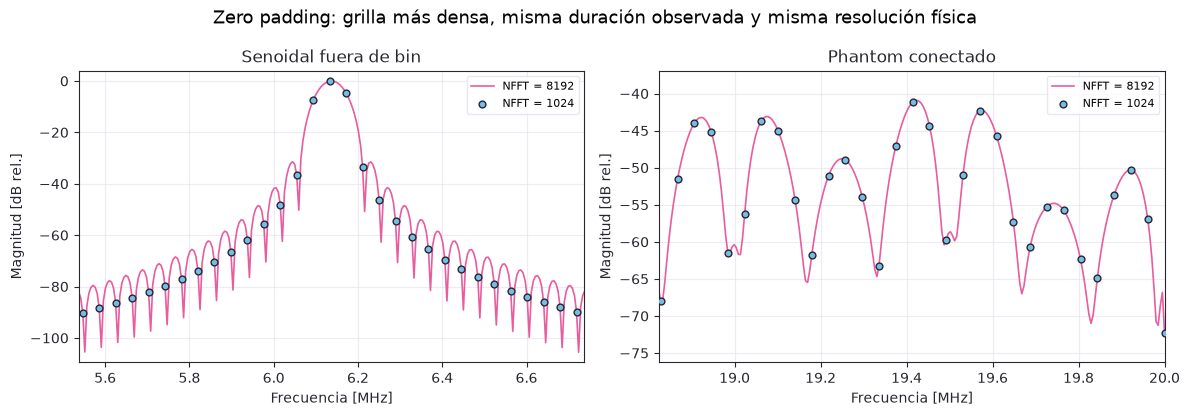

,N_muestras,NFFT,duracion_us,separacion_grilla_kHz
0,1024,1024,25.6,39.062500
1,1024,8192,25.6,4.882812


In [4]:
f0_padding = 6.137e6
tt_padding = np.arange(N) / fs
xx_padding = np.sin(2 * np.pi * f0_padding * tt_padding)

casos_padding = [
    ("Senoidal fuera de bin", xx_padding, f0_padding),
    ("Phantom conectado", ventana_phantom, None),
]

fig, ejes = plt.subplots(1, 2, figsize=(12, 4.2), constrained_layout=True)
for eje, (titulo, xx, frecuencia_central) in zip(ejes, casos_padding, strict=True):
    f_n, mag_n, _ = fft_magnitude(xx, fs, n_fft=N, window="hann", detrend=True)
    f_8n, mag_8n, _ = fft_magnitude(
        xx, fs, n_fft=NFFT, window="hann", detrend=True
    )
    if frecuencia_central is None:
        frecuencia_central = f_8n[np.argmax(mag_8n)]

    mag_8n_db = 20 * np.log10(np.maximum(mag_8n, 1e-15))
    mag_n_db = 20 * np.log10(np.maximum(mag_n, 1e-15))
    eje.plot(
        f_8n / 1e6,
        mag_8n_db,
        color=COLORES["rosa"],
        lw=1.2,
        label="NFFT = 8192",
    )
    eje.scatter(
        f_n / 1e6,
        mag_n_db,
        color=COLORES["azul_pastel"],
        edgecolor=COLORES["gris_texto"],
        s=24,
        label="NFFT = 1024",
        zorder=3,
    )
    limite_bajo = max(0.0, frecuencia_central / 1e6 - 0.6)
    limite_alto = min(fs / 2e6, frecuencia_central / 1e6 + 0.6)
    eje.set_xlim(limite_bajo, limite_alto)
    mascara_8n = (f_8n / 1e6 >= limite_bajo) & (f_8n / 1e6 <= limite_alto)
    mascara_n = (f_n / 1e6 >= limite_bajo) & (f_n / 1e6 <= limite_alto)
    valores_visibles = np.concatenate([mag_8n_db[mascara_8n], mag_n_db[mascara_n]])
    eje.set_ylim(np.min(valores_visibles) - 4, np.max(valores_visibles) + 4)
    eje.set_title(titulo)
    eje.set_xlabel("Frecuencia [MHz]")
    eje.set_ylabel("Magnitud [dB rel.]")
    eje.legend(fontsize=8)

fig.suptitle(
    "Zero padding: grilla más densa, misma duración observada y misma resolución física",
    fontsize=13,
)
save_figure(fig, FIGURES_DIR / "nb03_zero_padding.png")
plt.show()

tabla_padding = pd.DataFrame(
    [
        {
            "N_muestras": N,
            "NFFT": N,
            "duracion_us": N / fs * 1e6,
            "separacion_grilla_kHz": fs / N / 1e3,
        },
        {
            "N_muestras": N,
            "NFFT": NFFT,
            "duracion_us": N / fs * 1e6,
            "separacion_grilla_kHz": fs / NFFT / 1e3,
        },
    ]
)
tabla_padding.to_csv(TABLES_DIR / "nb03_zero_padding.csv", index=False)
display(tabla_padding)


 con 8192 puntos la curva y la ubicación visual del máximo quedan más
finas.  el zero padding interpola muestras de la DFT y ayuda a leer la
posición de un pico.  no agrega tiempo de observación ni permite separar dos
componentes que la ventana original de 1024 muestras no podía resolver.


## Potencia relativa por bandas

Para cerrar, resumo la PSD mediana de las 100 ventanas L de cada muestra en cuatro bandas
anchas de 5 MHz. Este gráfico es un complemento de las curvas, no su reemplazo.


,clase,banda_1,banda_2,banda_3,banda_4
0,Fondo,0.2463,0.1588,0.2921,0.3027
1,Phantom,0.2556,0.1492,0.2794,0.3158


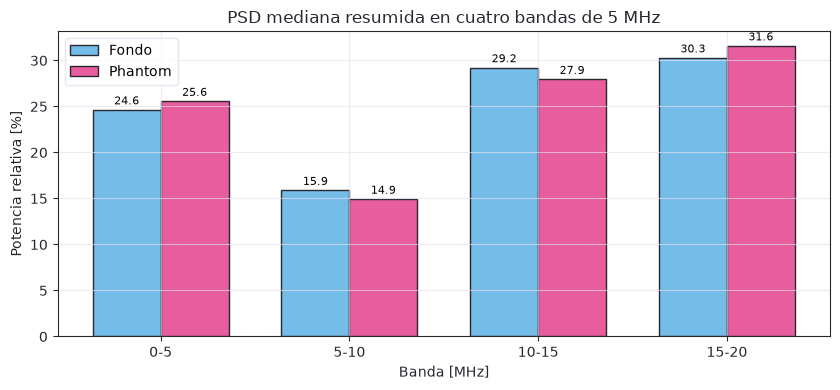

In [5]:
nperseg = 256
bandas_hz = [(0, 5e6), (5e6, 10e6), (10e6, 15e6), (15e6, 20e6)]
etiquetas = ["0-5", "5-10", "10-15", "15-20"]
filas_bandas = []

for clase, ventanas in [
    ("Fondo", entrada_fondo.window_sets["L"]),
    ("Phantom", entrada_phantom.window_sets["L"]),
]:
    psd_ventanas = []
    for xx in ventanas:
        ff_psd, psd = welch_psd(
            xx, fs, nperseg=nperseg, noverlap=nperseg // 2, window="hann"
        )
        psd_ventanas.append(psd)
    psd_mediana = np.median(np.asarray(psd_ventanas), axis=0)
    potencias = band_power(ff_psd, psd_mediana, bandas_hz)
    total_bandas = sum(potencias.values())
    fila = {"clase": clase}
    for indice in range(1, 5):
        fila[f"banda_{indice}"] = potencias[f"potencia_banda_{indice}"] / total_bandas
    filas_bandas.append(fila)

tabla_bandas = pd.DataFrame(filas_bandas)
tabla_bandas.to_csv(TABLES_DIR / "nb03_potencia_relativa_bandas.csv", index=False)
display(tabla_bandas.round(4))

x = np.arange(4)
ancho = 0.36
fig, eje = plt.subplots(figsize=(8.5, 4))
eje.bar(
    x - ancho / 2,
    tabla_bandas.loc[0, [f"banda_{i}" for i in range(1, 5)]],
    ancho,
    color=COLORES["azul_pastel"],
    edgecolor=COLORES["gris_texto"],
    label="Fondo",
)
eje.bar(
    x + ancho / 2,
    tabla_bandas.loc[1, [f"banda_{i}" for i in range(1, 5)]],
    ancho,
    color=COLORES["rosa"],
    edgecolor=COLORES["gris_texto"],
    label="Phantom",
)
eje.set_xticks(x, etiquetas)
eje.set_xlabel("Banda [MHz]")
eje.set_ylabel("Potencia relativa [%]")
eje.set_title("PSD mediana resumida en cuatro bandas de 5 MHz")
eje.legend()
eje.yaxis.set_major_formatter(lambda value, position: f"{100 * value:.0f}")
for contenedor in eje.containers:
    eje.bar_label(contenedor, labels=[f"{100 * valor:.1f}" for valor in contenedor.datavalues],
                  padding=2, fontsize=8)
save_figure(fig, FIGURES_DIR / "nb03_potencia_relativa_bandas.png")
plt.show()


 ambas muestras reparten potencia en todo el rango, pero no en las mismas
proporciones.  integrar por bandas transforma una curva extensa en
cuatro números comparables y después puede extenderse a las 20 bandas del detector.
 las bandas anchas ocultan picos estrechos y los porcentajes dependen de la
parte L y de estas muestras excluidas concretas.
